In [1]:
import numpy as np
import scipy.constants as sc
import matplotlib.pyplot as plt
from pygmid import Lookup as lk
from scipy.interpolate import interp1d
from scipy.interpolate import CubicSpline
pmos4 = lk('../lookup_table/035/pmos4.mat')
nmos4 = lk('../lookup_table/035/nmos4.mat')
# Interpolation function
def interp1(x, y, value):
    # Perform cubic interpolation using interp1d
    f = interp1d(x, y, kind='cubic', fill_value=-1, bounds_error=False)
    return f(value)

5T OTA
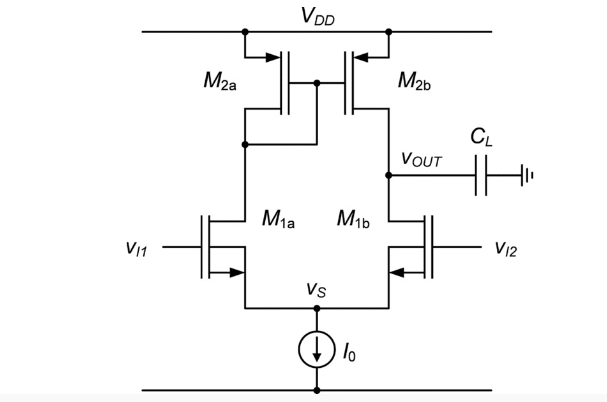
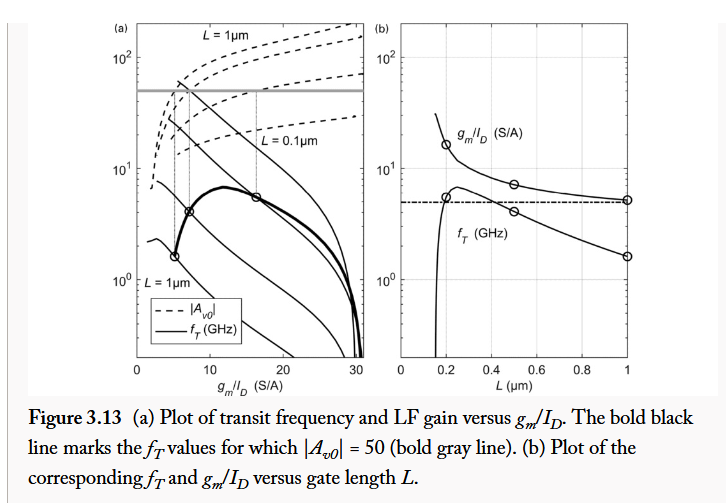  
Sizing at constant gain, for 1 max frequency, 2 min current for max frequency*0.8

In [2]:
#Specification
AV_spec = 1000
CL = 1e-12
VDD = 2.7
V_IC = 1.35

In [3]:
#Hypothèse : L et GM
#L1 = L2
#Sizing at constant gain, for 
# 1) max frequency
# 2) min current for max frequency*0.8

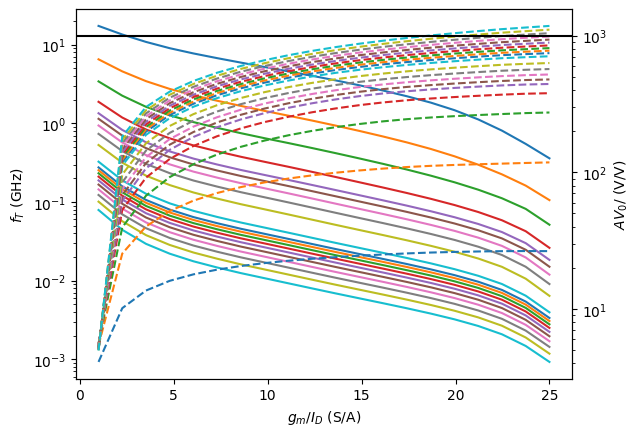

In [4]:
#Plot of AV0 and FT versus gm/id
Npoint = 20
gmid_test = np.linspace(1.0,25.0,Npoint)
#L_test = nmos4['L']
L_test = np.linspace(.35,10.0,Npoint)

#AV0 = gmID1 / (gdsID1 + gdsID2)
#FU = gm1/(2*3.14159*CL)
gdsID1 = nmos4.lookup('GDS_ID', GM_ID=gmid_test, L=L_test)
gdsID2 = pmos4.lookup('GDS_ID', GM_ID=gmid_test, L=L_test)

fT = nmos4.lookup('GM_CGG', GM_ID=gmid_test, L=L_test) /(2*3.14159) * 1e-9
AV0 = gmid_test / (gdsID1 + gdsID2)
#AV0 = nmos4.lookup('GM_GDS', GM_ID=gmid_test, L=L_test)


fig, ax1 = plt.subplots()
ax1.semilogy(gmid_test, fT.transpose())
plt.xlabel('$g_m/I_D$ (S/A)')
plt.ylabel(r'$f_T$ (GHz)')
ax2 = ax1.twinx()
ax2.semilogy(gmid_test, AV0.transpose(),linestyle='--')
plt.ylabel(r'$AV_0/$ (V/V)')
#ax1.legend(loc='center right', bbox_to_anchor=(1.3, 0.5), title='L', labels=L_test.tolist())
plt.axhline(y=AV_spec, color='k', linestyle='solid')


plt.show()

Pour un gain de  1000
La FT_max est de GHz 0.0038342729992678704
Pour la FT maximum, il faut L = :  10.0
Pour la FT maximum, il faut gmid = :  18.637873614328804


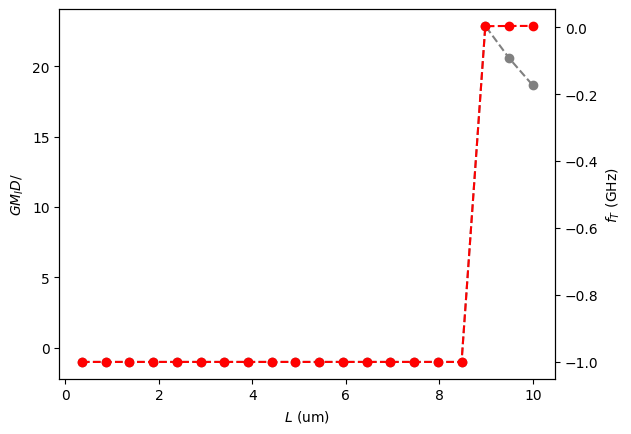

In [5]:
#Plot of GM_ID and FT for each L where AV0 == AV_spec
# On veut les valeur gmID et FT pour lesquel AV0 = AVREF
gmID1 = np.zeros(L_test.size)
ft1 = np.zeros(L_test.size)
for k in range(len(L_test)):
    gmID1[k] = interp1(AV0[k], gmid_test, AV_spec)
    ft1[k] = interp1(gmid_test, fT[k], gmID1[k])

plt.plot(L_test, gmID1,marker='o', markersize=5, markeredgewidth=2, linestyle='--', color='gray')
plt.xlabel('$L$ (um)')
plt.ylabel(r'$GM_ID/$')
plt.twinx()
plt.plot(L_test, ft1,marker='o', markersize=5, markeredgewidth=2, linestyle='--', color='red')
plt.ylabel(r'$f_T$ (GHz)')


#plt.show()

L_for_FTMAX = L_test[np.argmax(ft1)]
gmID_for_FTMAX = gmID1[np.argmax(ft1)]
FT_MAX = max(ft1)

print("Pour un gain de ", AV_spec)
print("La FT_max est de GHz", FT_MAX)
print("Pour la FT maximum, il faut L = : ", L_for_FTMAX)
print("Pour la FT maximum, il faut gmid = : ", gmID_for_FTMAX)

In [6]:
L12 = L_for_FTMAX
gmID_for_FTMAX = gmID_for_FTMAX * 1
gmID1 = gmID_for_FTMAX
gmID2 = gmID_for_FTMAX
FU = FT_MAX *1e9
FU = 100e3


CselfLoading = 0

#gm and ID, from Spec and Hypothesis
gm1 = 2*3.14159*FU*CL
ID = gm1 / gmID1
#VGS from lookupVGS, L and GM_ID
# Find VDS1 and 
VGS1 = nmos4.lookupVGS(GM_ID=gmID1, L=L12, VDS=0.6, VSB=0) #Fist estimation with vds default
VGS2 = pmos4.lookupVGS(GM_ID=gmID2, L=L12, VDS=0.6, VSB=0) #Fist estimation with vds default
VGS2 = pmos4.lookupVGS(GM_ID=gmID2, L=L12, VDS=VGS2, VSB=0) #Second with VDS = VGS (current mirror)
VS = V_IC - VGS1
VD = VDD - VGS2
VDS1 = VD - VS
VGS1 = nmos4.lookupVGS(GM_ID=gmID1, L=L12, VDS=VDS1, VSB=0) #Second with VDS
##Design terminé##

#Calcul Gain
gdsID1 = nmos4.look_up('GDS_ID', GM_ID=gmID1, VDS=VDS1, L=L12, VSB=0)
gdsID2 = pmos4.look_up('GDS_ID', GM_ID=gmID2, VDS=VDS1, L=L12, VSB=0)
AV0 = gmID1 / (gdsID1 + gdsID2)

print('AV0 = %.2F' % AV0)
print('gm1 = %.2F uS' % (gm1 * 1e6))
print('VDS1 = %.2F' % VDS1)


for m in range(1,10,1):
    #self loading
    gm1 = 2*3.14159*FU*(CL+CselfLoading)
    ID = gm1 / gmID1
    #Denormalization
    JD1 = nmos4.lookup('ID_W', GM_ID=gmID1, VDS=VDS1, L=L12, VSB=0)
    JD2 = pmos4.lookup('ID_W', GM_ID=gmID2, VDS=VGS2, L=L12, VSB=0)
    W1 = ID/JD1
    W2 = ID/JD2
    print('ID = %.2F uA' % (ID* 1e6))
    print('W1 = %.2F um' % (W1))
    print('W2 = %.2F um' % (W2))
    CDD1 = W1 * nmos4.look_up('CDD_W', GM_ID=gmID1, L=L12, VSB=0)
    CDD2 = W2 * pmos4.look_up('CDD_W', GM_ID=gmID2, L=L12, VSB=0)
    CselfLoading = CDD1 + CDD2


AV0 = 965.04
gm1 = 0.63 uS
VDS1 = 1.16
ID = 0.03 uA
W1 = 0.85 um
W2 = 2.69 um
ID = 0.03 uA
W1 = 0.86 um
W2 = 2.71 um
ID = 0.03 uA
W1 = 0.86 um
W2 = 2.71 um
ID = 0.03 uA
W1 = 0.86 um
W2 = 2.71 um
ID = 0.03 uA
W1 = 0.86 um
W2 = 2.71 um
ID = 0.03 uA
W1 = 0.86 um
W2 = 2.71 um
ID = 0.03 uA
W1 = 0.86 um
W2 = 2.71 um
ID = 0.03 uA
W1 = 0.86 um
W2 = 2.71 um
ID = 0.03 uA
W1 = 0.86 um
W2 = 2.71 um


In [7]:
print('Adjuste gm if gain is not accurate, due to VDS approximation at the beginning')
print('AV0 = %.2F dB' % (20*np.log10(AV0)))
print('AV0 = %.2F V/V' % (AV0))
print('gm1 = %.2F uS' % (gm1 * 1e6))    
print('ID = %.3F uA' % (ID* 1e6))
print('W1 = %.2F um' % (W1))
print('W2 = %.2F um' % (W2))
print('L1 = %.2F um' % (L12))
print('L2 = %.2F um' % (L12))
print('gmID1 = %.2F' % (gmID1))
print('gmID2 = %.2F' % (gmID2))
print('FU = %.2F MHz' % (FU*1e-6))

Adjuste gm if gain is not accurate, due to VDS approximation at the beginning
AV0 = 59.69 dB
AV0 = 965.04 V/V
gm1 = 0.63 uS
ID = 0.034 uA
W1 = 0.86 um
W2 = 2.71 um
L1 = 10.00 um
L2 = 10.00 um
gmID1 = 18.64
gmID2 = 18.64
FU = 0.10 MHz
